In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_user = pd.read_csv("C:/Work/Analytics/3_user_data.csv",
                      encoding = 'windows-1251')
df_logs = pd.read_csv("C:/Work/Analytics/3_logs.csv",
                      encoding = 'windows-1251')

In [4]:
# Размер таблицы, Типы данных, Описательная статистика, Пропущенные значения

print(df_user.head(10))

   client  premium  age
0   46346    False   58
1    4391    False   55
2   27372    False   64
3   11989    False   44
4   60664    False   49
5   78605    False   36
6   14477    False   34
7   77451    False   49
8   35036    False   48
9   11623    False   42


In [5]:
print(df_user.describe())

             client          age
count   2954.000000  2954.000000
mean   50767.886594    44.196005
std    28800.505847    14.248336
min       40.000000    20.000000
25%    25639.500000    32.000000
50%    51569.500000    44.000000
75%    75963.250000    56.000000
max    99973.000000    69.000000


In [6]:
print(df_user.describe(percentiles=[0.1, 0.3, 0.9]))

             client          age
count   2954.000000  2954.000000
mean   50767.886594    44.196005
std    28800.505847    14.248336
min       40.000000    20.000000
10%    10372.600000    25.000000
30%    31398.800000    35.000000
90%    90273.600000    64.000000
max    99973.000000    69.000000


In [7]:
print(df_logs.astype('object').describe())

        client success platform        time
count     4500    4500     4500        4500
unique    4011       2        3        4376
top      61468    True    phone  1585429173
freq        42    3289     2753           3


In [70]:
df_logs.dtypes

client      int64
success      bool
platform      str
time        int64
dtype: object

In [69]:
# Сколько уникальных значений принимает переменная platform?
df_logs.platform.unique()

<StringArray>
['phone', 'computer', 'tablet']
Length: 3, dtype: str

In [8]:
print(df_logs.head(10))

   client  success  platform        time
0   40177     True     phone  1585412212
1   61468     True     phone  1585425658
2   35604    False     phone  1585459894
3    9961     True     phone  1585400189
4   10931     True  computer  1585468629
5   41928     True     phone  1585446772
6   48925     True     phone  1585467880
7   32167     True  computer  1585457972
8   83888     True     phone  1585422273
9   71087     True  computer  1585458446


In [64]:
#какой клиент совершил больше всего успешных операций

#client_top = df_logs.query('success == True') \
#    .groupby('client') \
#    .count()

#client_top = df_logs[df_logs['success'] == True].groupby('client').size()

client_top = df_logs[df_logs['success'] == True]['client'].value_counts().reset_index().query('count == count.max()')
print(client_top)


# второй вариант кода
#client_top = (
#    df_logs.query('success == True')['client']
#    .value_counts()
#)

#client_top[client_top == client_top.max()]

   client  count
0   61468     41
1   78349     41
2   61473     41
3   92584     41
4   36165     41
5   28719     41
6   82563     41
7   12179     41
8   52870     41


In [82]:
# С какой платформы осуществляется наибольшее количество успешных операций?

successful_platform = df_logs.query('success == True')['platform'].value_counts().reset_index()

print(successful_platform)

# successful_platform = df_logs[df_logs['success'] == True]['platform'].value_counts()
#print(successful_platform)

   platform  count
0     phone   2019
1  computer   1090
2    tablet    180


In [91]:
# Какая платформа наиболее популярна среди премиумных клиентов?

df = pd.merge(df_user, df_logs, on='client')

platform_premium = df.query('premium == True').platform.value_counts()

print(platform_premium)

platform
phone       246
computer    150
tablet       24
Name: count, dtype: int64


In [94]:
print(df)

      client  premium  age  success  platform        time
0      46346    False   58     True     phone  1585452839
1       4391    False   55    False     phone  1585409861
2      27372    False   64    False     phone  1585446018
3      11989    False   44     True  computer  1585403698
4      60664    False   49     True     phone  1585406918
...      ...      ...  ...      ...       ...         ...
3434   19411    False   29     True     phone  1585400902
3435   61579    False   50     True     phone  1585436158
3436   61221     True   64     True     phone  1585440218
3437   29863    False   46     True    tablet  1585443437
3438   78499    False   36    False     phone  1585425483

[3439 rows x 6 columns]


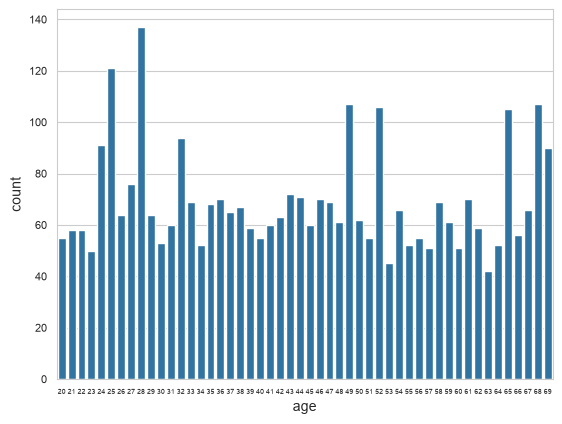

In [128]:
# Распределение возраста клиентов в зависимости от типа клиента
plt.rc('xtick', labelsize=5)
plt.rc('ytick', labelsize=8)
ax = sns.countplot(x = df.age,
    )

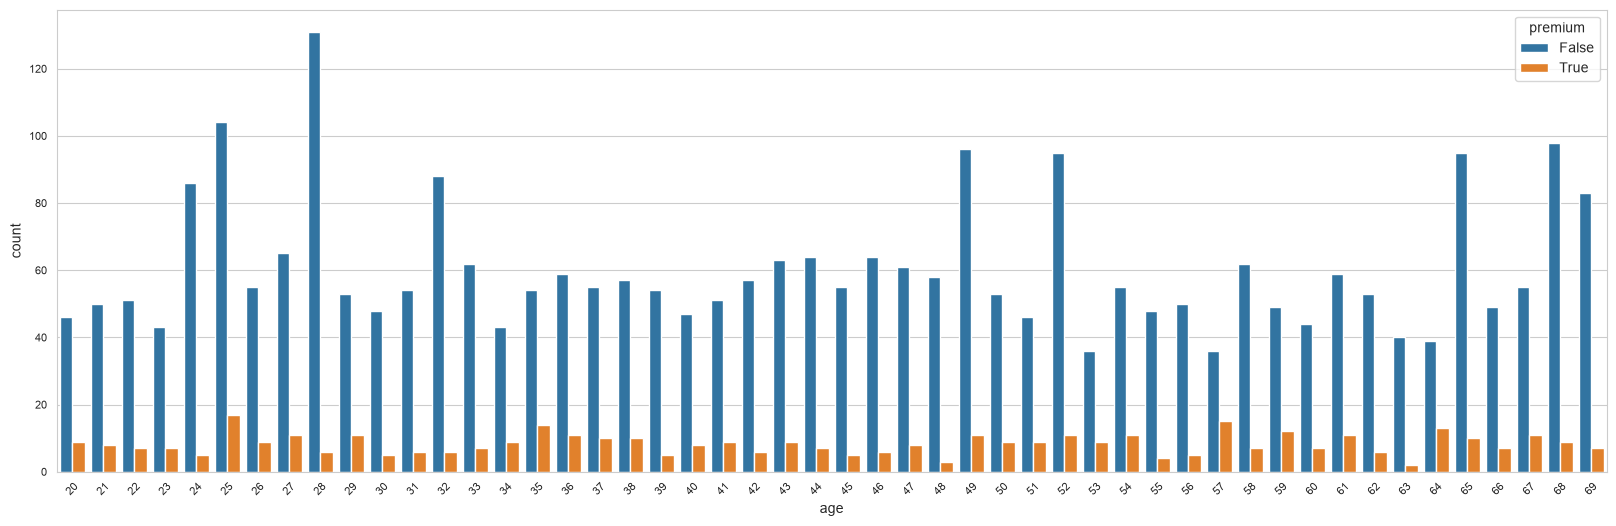

In [134]:
# или так
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='age',
    hue='premium',

)

plt.xticks(rotation=45, fontsize=8)
plt.show()

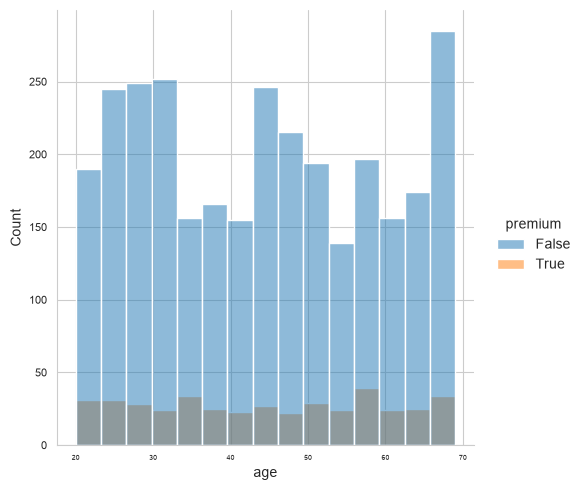

In [138]:
# или так
sns.displot(
    data=df,
    x='age',
    hue='premium',
    kind='hist'
)

In [173]:
# Посчитать, сколько успешных операций совершил каждый клиент.
# Построить распределение этих количеств.

successful_operations = (
    df_logs.query('success == True')['client']
    .value_counts()
)

distribution = successful_operations.value_counts()

print(distribution)

count
1     2791
2       43
41       9
40       1
3        1
Name: count, dtype: int64


<Axes: xlabel='age', ylabel='count'>

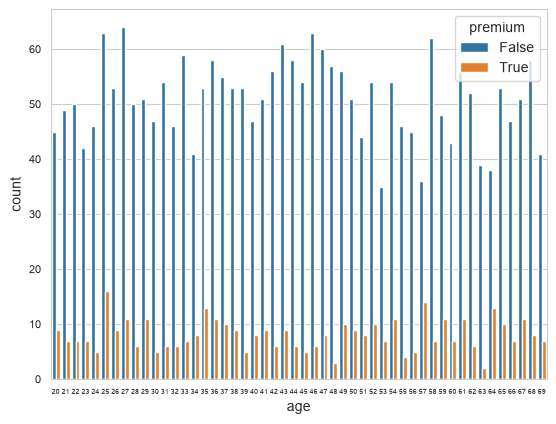

In [175]:
sns.countplot(
    data=df_user,
    x='age',
    hue='premium'
)

In [186]:
# Для платформы computer посмотреть число успешных операций у клиентов разных возрастов

computer_client = df.query('success == True and platform == "computer"').groupby('age', as_index=False).agg({'success': 'count'}) \
    .rename(columns={'success' : 'count_success'}).sort_values('count_success', ascending=False)

print(computer_client)

    age  count_success
8    28             49
29   49             33
5    25             33
12   32             27
48   68             26
4    24             26
49   69             24
45   65             23
32   52             22
34   54             22
39   59             20
28   48             19
23   43             19
15   35             19
42   62             18
24   44             18
17   37             17
38   58             17
9    29             17
13   33             17
44   64             16
22   42             16
41   61             16
26   46             16
27   47             16
37   57             15
40   60             15
3    23             15
31   51             15
47   67             15
1    21             15
20   40             15
7    27             14
6    26             14
11   31             14
43   63             14
30   50             13
18   38             13
16   36             12
0    20             11
19   39             11
25   45             11
21   41    

<Axes: xlabel='age', ylabel='count_success'>

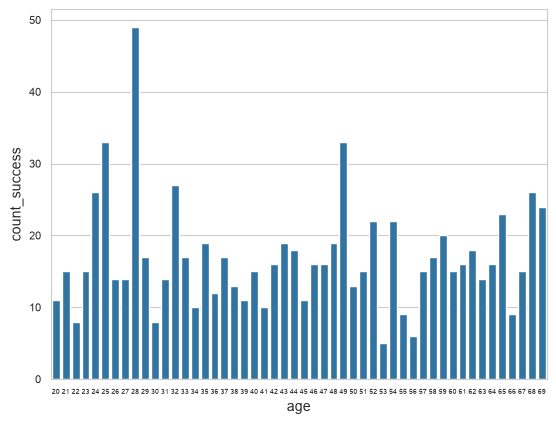

In [187]:
sns.barplot(x=computer_client.age, y= computer_client.count_success)